In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Delfin_Cardiometabolico/framingham.csv')
print("Dataset cargado correctamente")
print("Forma:", df.shape)

Mounted at /content/drive
Dataset cargado correctamente
Forma: (4240, 16)


In [3]:
print("Valores faltantes por columna:")
print(df.isnull().sum())
print("\nPorcentaje de valores faltantes:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valrores faltantes por columna:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Porcentaje de los valores faltantes:
male               0.00
age                0.00
education          2.48
currentSmoker      0.00
cigsPerDay         0.68
BPMeds             1.25
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.18
sysBP              0.00
diaBP              0.00
BMI                0.45
heartRate          0.02
glucose            9.15
TenYearCHD         0.00
dtype: float64


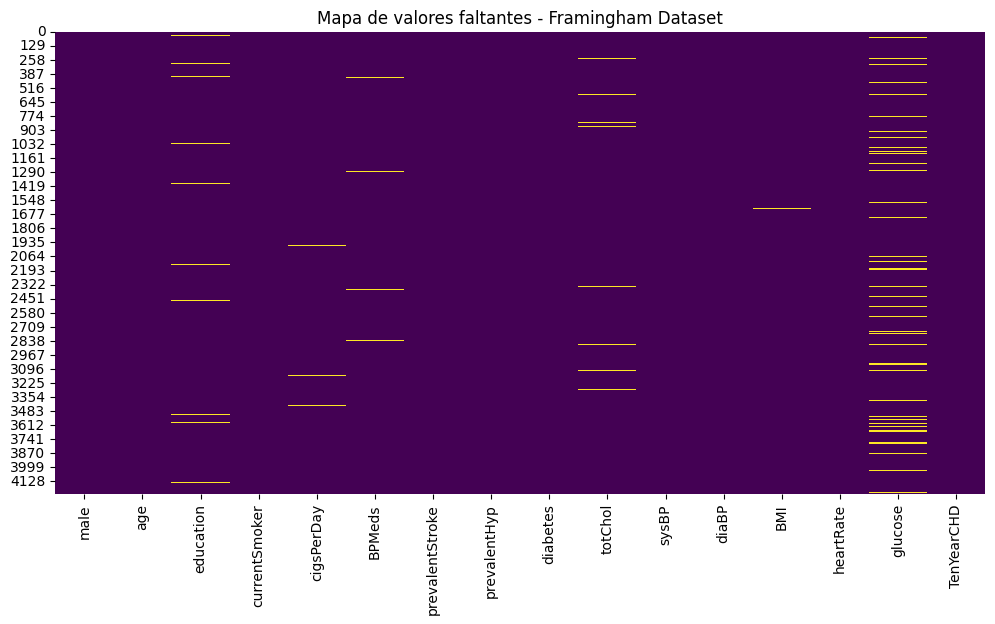

In [ ]:
plt.figure(figsize = (12, 6))
sns.heatmap(df.isnull(), cbar = False, cmap = 'viridis')
plt.title("Valores faltantes en el dataset")
plt.title('Mapa de valores faltantes - Framingham Dataset')
plt.show()

In [4]:
df_clean = df.copy()
df_clean.fillna(df.median(numeric_only=True), inplace=True)
print("Valores faltantes después de imputación:")
print(df_clean.isnull().sum())

Valores faltantes después de imputación:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


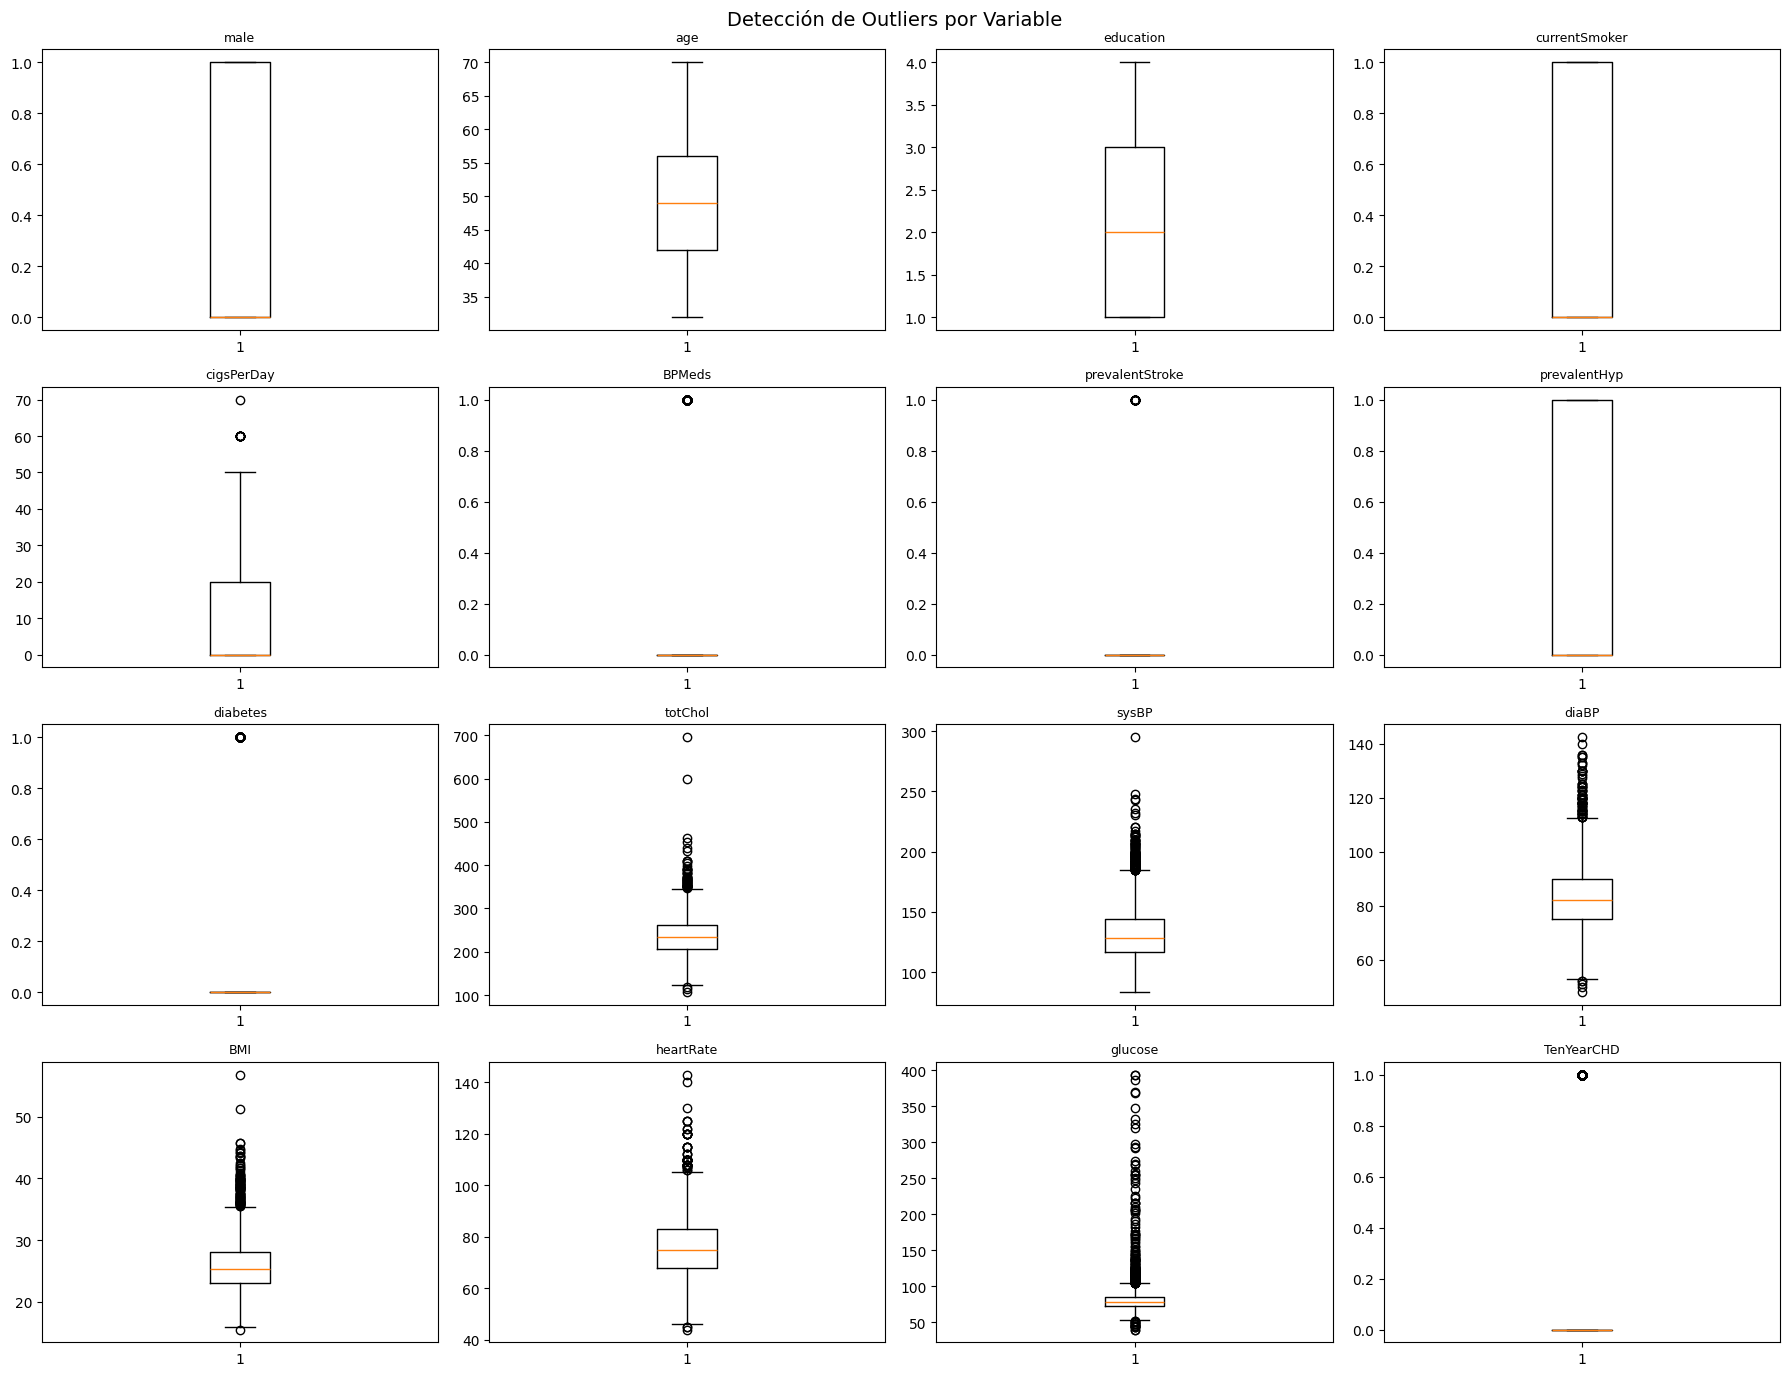

In [10]:
cols_numericas = df_clean.select_dtypes(include='number').columns
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for i, col in enumerate(cols_numericas):
    if i < 16:
        axes[i//4][i%4].boxplot(df_clean[col].dropna())
        axes[i//4][i%4].set_title(col, fontsize=9)

plt.suptitle('Detección de Outliers por Variable', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1

mascara = ~((df_clean < (Q1 - 1.5 * IQR)) |
            (df_clean > (Q3 + 1.5 * IQR))).any(axis=1)

df_filtrado = df_clean[mascara]
print(f"Registros originales: {len(df_clean)}")
print(f"Registros después de filtrar outliers: {len(df_filtrado)}")
print(f"Registros eliminados: {len(df_clean) - len(df_filtrado)}")

Registros originales: 4240
Registros después de filtrar outliers: 3090
Registros eliminados: 1150


/tmp/ipykernel_11597/492957246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=df_filtrado,
/tmp/ipykernel_11597/492957246.py:2: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(x='TenYearCHD', data=df_filtrado,


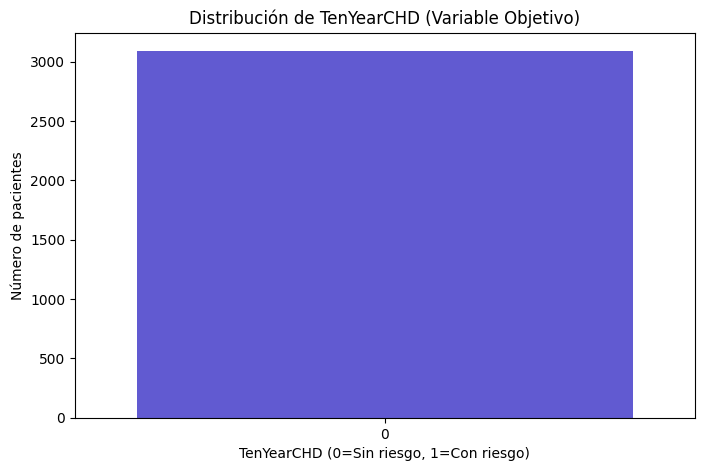

TenYearCHD
0    3090
Name: count, dtype: int64

Porcentaje:
TenYearCHD
0    100.0
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='TenYearCHD', data=df_filtrado,
              palette=['#4F46E5','#EF4444'])
plt.title('Distribución de TenYearCHD (Variable Objetivo)')
plt.xlabel('TenYearCHD (0=Sin riesgo, 1=Con riesgo)')
plt.ylabel('Número de pacientes')
plt.show()

print(df_filtrado['TenYearCHD'].value_counts())
print("\nPorcentaje:")
print((df_filtrado['TenYearCHD'].value_counts(normalize=True)*100).round(2))

In [11]:
df_filtrado.to_csv('/content/drive/MyDrive/Delfin_Cardiometabolico/framingham_clean.csv',
                   index=False)
print("Dataset limpio guardado correctamente en Drive")

Dataset limpio guardado correctamente en Drive
